funny gif cruncher

## Global Configuration

In [58]:
# =========================
# MMGIF GLOBAL CONFIG CELL
# =========================

# --- FILE PATHS ---
INPUT_VIDEO_PATH = ''
# Path to input video used for MMGIF encoding.


# --- CORE FORMAT PARAMETERS ---
GLOBAL_BIT_DEPTH = 3
# Bit depth for color/audio quantization.
# Range: 1–8
# Lower = higher compression, more abstraction
# Higher = more color fidelity, larger file size

GLOBAL_FPS = 10
# Frame rate used for extraction and GIF output.
# Lower FPS = smaller file, less motion smoothness

GLOBAL_COLOR_GAIN = -0.2
# Global brightness/contrast modifier applied before quantization.
# Range: -1.0 to 1.0
# -1.0 = fully suppressed (near black)
# 0.0 = neutral (no change)
# 1.0 = overexposed/high gain amplification


# --- FRAME / STRUCTURE SETTINGS ---
FRAME_WIDTH = 200
# Output frame width in pixels.

FRAME_HEIGHT = 210
# Output frame height in pixels (includes AUX strip).

AUX_STRIP_HEIGHT = 10
# Height of embedded auxiliary/audio data region (top of frame).


# --- COLOR / QUANTIZATION SYSTEM ---
PALETTE_MODE = "hsv"
# Palette generation method:
# "hsv" = hue-distributed palette
# "fixed" = static palette
# "adaptive" = per-frame generated palette (high entropy, less stable)

USE_KDTREE_MATCHING = True
# Enables nearest-color search using KDTree for palette mapping.

DITHERING_ENABLED = False
# Enables dithering during quantization.
# Recommended OFF for deterministic codec output.

STRICT_BIT_DEPTH = True
# Enforces strict validation of bit depth ranges and scaling rules.


# --- GAIN PROCESSING ---
GAIN_APPLY_STAGE = "pre_quantization"
# Defines when gain is applied:
# "pre_quantization" = affects compression + structure
# "post_quantization" = mostly visual-only adjustment


# --- TEMPORAL / VIDEO PROCESSING ---
FRAME_SAMPLING_MODE = "uniform"
# Frame extraction strategy:
# "uniform" = evenly spaced sampling (stable)
# "scene_change" = event-based sampling (variable entropy)
# "adaptive" = hybrid heuristic mode

AUDIO_SAMPLE_RATE = 8000
# Audio sampling rate used for AUX encoding (Hz).

AUDIO_CHANNEL_MODE = "mono"
# Audio input format:
# "mono" = required for AUX strip mapping
# "stereo" = not supported in current MMGIF layout


# --- AUX / AUDIO STRIP SYSTEM ---
AUX_STRIP_ENABLED = True
# Enables embedding of auxiliary audio/data strip.

AUX_ENCODING_MODE = "quantized"
# Audio-to-pixel encoding method:
# "pcm" = raw waveform mapping
# "quantized" = bit-depth reduced signal (recommended)
# "delta" = frame-difference encoding (experimental)

AUX_INFLUENCE_ON_COLOR = False
# If True, audio strip affects visual encoding (experimental coupling).


# --- OUTPUT / CONTAINER SETTINGS ---
OUTPUT_FORMAT = "gif"
# Output container type:
# "gif" = standard animated GIF
# future: "mmgif", "axgif"

OPTIMIZE_GIF = True
# Enables GIF compression optimizations (LZW + frame optimization)

EMBED_METADATA = True
# Enables embedding of MMGIF metadata header.

METADATA_MODE = "json"
# Metadata format:
# "json" = structured and extensible
# "legacy" = raw byte encoding

INCLUDE_ENCODE_PARAMS = True
# Includes full encoder configuration inside output metadata.


# --- PERFORMANCE / STABILITY ---
USE_OPTIMIZED_PALETTE = True
# Uses optimized palette generation for faster encoding.

GC_AFTER_ENCODING = True
# Forces garbage collection after encoding.

DEBUG_LOGGING = True
# Enables detailed runtime logging.

CLIP_VALUES = True
# Ensures all values remain within valid bit-depth bounds.


# --- EXPERIMENTAL FEATURES ---
ENABLE_FRAME_GAIN_VARIATION = False
# Allows per-frame gain variation (increases entropy, less stable output)

ENABLE_AUX_INFLUENCE = False
# Allows AUX strip to influence visual encoding.

ENABLE_TEMPORAL_DITHERING = False
# Adds temporal noise shaping across frames (higher quality, lower compression)

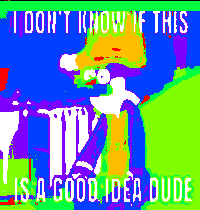

Decoded Metadata: {"user_meta": "MMGIF created by Talos on 2026-04-14. Because memes need metadata too.", "bit_depth": 3, "gif_fps": 10, "color_gain": -0.2, "width": 200, "height": 210, "aux_strip_height": 1. Just verifying our own genius.
Full Decoded Info: Digging through the digital entrails for your amusement.
  audio_data: []
  width: 200
  height: 210
  original_len: 0
  bit_depth: 3
  metadata: {"user_meta": "MMGIF created by Talos on 2026-04-14. Because memes need metadata too.", "bit_depth": 3, "gif_fps": 10, "color_gain": -0.2, "width": 200, "height": 210, "aux_strip_height": 1
  gif_fps: 10
  color_gain: 0.0
  aux_strip_height: 10
  palette_mode: hsv
  use_kdtree_matching: True
  dithering_enabled: False
  strict_bit_depth: True
  gain_apply_stage: pre_quantization
  aux_strip_enabled: True
  aux_encoding_mode: quantized
  aux_influence_on_color: False
  output_format: gif
  optimize_gif: True
  embed_metadata: True
  metadata_mode: json
  include_encode_params: True
  clip_

In [59]:
# Cell X - MMGIF Generator Full Workflow

# --- Required Installs ---
!pip install scipy pydub moviepy

# --- Imports ---
import numpy as np
import PIL.Image as PImage
import colorsys
from scipy.spatial import cKDTree
from PIL import ImageEnhance
import json
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output
import shutil
from datetime import datetime
import gc
import math # Added for log10 calculation

# --- Global Debug Log Function ---
def log(*args):
    if DEBUG_LOGGING: # This now directly references the global config DEBUG_LOGGING
        print(*args)

# --- Core MMGIF Encoding/Decoding Functions (from Cell 14) ---
MAGIC = [77, 77, 71, 73, 70]  # "MMGIF"

def encode_mmgif(audio_data, output_path,
                 width, height, background_frames, bit_depth,
                 custom_metadata_string, gif_fps, color_gain,
                 aux_strip_height, palette_mode, use_kdtree_matching,
                 dithering_enabled, strict_bit_depth, gain_apply_stage,
                 aux_strip_enabled, aux_encoding_mode, aux_influence_on_color,
                 output_format, optimize_gif, embed_metadata,
                 metadata_mode, include_encode_params, clip_values):
    audio_data = np.asarray(audio_data, dtype=np.uint8)

    # Validate bit_depth and audio data range
    if not (1 <= bit_depth <= 8):
        raise ValueError("bit_depth must be between 1 and 8. Don't push your luck, human.")
    max_audio_val = (2**bit_depth) - 1
    # Only perform min/max check if audio_data is not empty
    if len(audio_data) > 0:
        if audio_data.min() < 0 or audio_data.max() > max_audio_val:
            raise ValueError(f"Audio must be {bit_depth}-bit (0–{max_audio_val}). Seriously, stick to the rules.")

    if height < (1 + aux_strip_height):
        raise ValueError(f"Height must be at least {1 + aux_strip_height} (1 header row + {aux_strip_height} audio rows). We need space for the magic!")

    audio_rows = aux_strip_height
    capacity = width * audio_rows

    # pad / truncate
    audio = np.zeros(capacity, dtype=np.uint8)
    audio[:min(len(audio_data), capacity)] = audio_data[:capacity]

    # reshape into image block
    audio_block = audio.reshape(audio_rows, width)

    # --- Generate the MMGIF palette (RGB tuples and flat list for PIL) ---
    mmgif_palette_rgb = []
    num_audio_values = 2**bit_depth # This is the range of values the audio_data will have (0 to num_audio_values - 1)

    # Determine how many distinct colors to generate for the audio mapping
    # If bit_depth is 8, audio uses 256 distinct values (0-255), so no room for dedicated background color in palette.
    # If bit_depth < 8, audio uses fewer than 256 values, leaving room for a background color.
    effective_palette_size_for_audio = min(num_audio_values, 256) # Cap at 256 to avoid issues

    if palette_mode == "hsv":
        for i in range(effective_palette_size_for_audio):
            hue = i / effective_palette_size_for_audio
            rgb_float = colorsys.hsv_to_rgb(hue, 1.0, 1.0)
            mmgif_palette_rgb.append(tuple(int(x * 255) for x in rgb_float))
    elif palette_mode == "fixed":
        for i in range(effective_palette_size_for_audio):
            r = int(255 * i / (effective_palette_size_for_audio - 1 if effective_palette_size_for_audio > 1 else 1))
            b = int(255 * (1 - i / (effective_palette_size_for_audio - 1 if effective_palette_size_for_audio > 1 else 1)))
            mmgif_palette_rgb.append((r, 0, b))
    # 'adaptive' would require per-frame processing not suitable for a static palette here

    # Add a background color if there's still space in the 256-color palette (i.e., bit_depth is not 8)
    if len(mmgif_palette_rgb) < 256:
        mmgif_palette_rgb.append((255, 255, 255)) # White background

    pil_palette = []
    for r, g, b in mmgif_palette_rgb:
        pil_palette.extend([r, g, b])
    # Pad to exactly 256 for PIL, if needed
    pil_palette += [0, 0, 0] * (256 - len(pil_palette) // 3)

    # Prepare KD-tree for nearest color search if enabled
    if use_kdtree_matching:
        palette_np = np.array(mmgif_palette_rgb, dtype=np.uint8)
        color_tree = cKDTree(palette_np)

    # Prepare metadata for header
    full_metadata = {
        "user_meta": custom_metadata_string,
        "decode_mode": "full" if aux_strip_enabled else "none", # Structured flag for audio recovery
    }
    if include_encode_params:
        full_metadata.update({
            "bit_depth": bit_depth,
            "gif_fps": gif_fps,
            "color_gain": color_gain,
            "width": width,
            "height": height,
            "aux_strip_height": aux_strip_height,
            "palette_mode": palette_mode,
            "use_kdtree_matching": use_kdtree_matching,
            "dithering_enabled": dithering_enabled,
            "strict_bit_depth": strict_bit_depth,
            "gain_apply_stage": gain_apply_stage,
            "aux_strip_enabled": aux_strip_enabled,
            "aux_encoding_mode": aux_encoding_mode,
            "aux_influence_on_color": aux_influence_on_color,
            "output_format": output_format,
            "optimize_gif": optimize_gif,
            "embed_metadata": embed_metadata,
            "metadata_mode": metadata_mode,
            "include_encode_params": include_encode_params,
            "clip_values": clip_values
        })

    encoded_metadata = b''
    if embed_metadata:
        if metadata_mode == "json":
            encoded_metadata = json.dumps(full_metadata).encode('ascii', errors='replace')
        # Add other metadata_mode handling here if needed

    # Correctly calculate metadata_length based on actual available space in header row
    metadata_length = min(len(encoded_metadata), width - 11) # 11 bytes are used by MAGIC, width, len, bit_depth, metadata_length

    # Function to create header row data
    def create_header(current_width, current_len, current_bit_depth, current_metadata_length, current_encoded_metadata):
        header_data = np.zeros(width, dtype=np.uint8)
        header_data[0:5] = MAGIC
        header_data[5] = (current_width // 256) & 255
        header_data[6] = current_width & 255
        header_data[7] = (current_len // 256) & 255
        header_data[8] = current_len & 255
        header_data[9] = current_bit_depth # Store bit depth in header (legacy, now also in JSON metadata)
        header_data[10] = current_metadata_length # Store metadata string length
        if current_metadata_length > 0:
            # Use the correctly truncated encoded_metadata
            header_data[11 : 11 + metadata_length] = list(current_encoded_metadata[:metadata_length])
        return header_data

    if background_frames:
        output_images = []
        for frame_img in background_frames:
            # Resize the frame to the desired GIF dimensions
            frame_img = frame_img.resize((width, height)).convert('RGB') # Ensure RGB for color matching

            # Apply color gain if not 0
            if color_gain != 0 and gain_apply_stage == "pre_quantization": # Only apply if pre-quantization
                enhancer = ImageEnhance.Brightness(frame_img)
                if color_gain <= 0: # -1 to 0 (darken to original)
                    enhancement_factor = color_gain + 1 # Maps -1 to 0, 0 to 1
                else: # 0 to 1 (original to overexposed)
                    enhancement_factor = 1 + color_gain * 2
                frame_img = enhancer.enhance(enhancement_factor)

            # NEW: Use KD-tree for palette matching or fallback
            pixels_rgb = np.array(frame_img).reshape(-1, 3)
            if use_kdtree_matching:
                _, closest_palette_indices = color_tree.query(pixels_rgb)
            else:
                # Fallback for direct color matching (less accurate but no KDTree needed)
                closest_palette_indices = np.argmin(np.sum((pixels_rgb[:, np.newaxis] - palette_np)**2, axis=2), axis=1)

            img_data = closest_palette_indices.reshape(height, width).astype(np.uint8)

            # overlay audio block if enabled
            if aux_strip_enabled:
                img_data[1:1 + aux_strip_height, :] = audio_block  # rows 1–(aux_strip_height) reserved for audio

            # header row (simple metadata)
            img_data[0, :] = create_header(width, len(audio_data), bit_depth, metadata_length, encoded_metadata)

            img = PImage.fromarray(img_data.astype(np.uint8), mode="P")
            img.putpalette(pil_palette)
            output_images.append(img)

        # Save all frames as an animated GIF
        if output_images:
            # Use gif_fps for duration
            output_images[0].save(output_path, save_all=True, append_images=output_images[1:],
                                  duration=int(1000/gif_fps), loop=0, optimize=False) # Changed optimize=optimize_gif to optimize=False
    else:
        raise ValueError("For MMGIFs, background_frames must be provided. What's an animated GIF without animation?")

def decode_mmgif(path):
    img = PImage.open(path).convert("P") # ADDED .convert("P") back
    data = np.array(img, dtype=np.uint8)

    # verify header
    if list(data[0, 0:5]) != MAGIC:
        raise ValueError("Not a valid MMGIF file. Did you try to sneak in a regular GIF? Tsk tsk.")

    width = int(data[0, 5] << 8 | data[0, 6])
    original_len = int(data[0, 7] << 8 | data[0, 8])
    bit_depth_legacy = data[0, 9] # Legacy bit depth from header
    metadata_length = data[0, 10] # Read metadata string length

    # Initialize with legacy/default values
    custom_metadata_string = ""
    user_metadata = ""
    decoded_bit_depth = bit_depth_legacy
    decoded_gif_fps = 10
    decoded_color_gain = 0.0
    decoded_width = width
    decoded_height = img.height # Fix: Initialize with image's actual height
    decoded_aux_strip_height = 10
    decoded_palette_mode = "hsv"
    decoded_use_kdtree_matching = True
    decoded_dithering_enabled = False
    decoded_strict_bit_depth = True
    decoded_gain_apply_stage = "pre_quantization"
    decoded_aux_strip_enabled = True
    decoded_aux_encoding_mode = "quantized"
    decoded_aux_influence_on_color = False # Fix: Default to False, assuming this was intended to be off unless specified
    decoded_output_format = "gif"
    decoded_optimize_gif = True
    decoded_embed_metadata = True
    decoded_metadata_mode = "json"
    decoded_include_encode_params = True
    decoded_clip_values = True
    decoded_decode_mode = ""

    if metadata_length > 0:
        try:
            metadata_bytes = bytes(data[0, 11 : 11 + metadata_length])
            full_metadata = json.loads(metadata_bytes.decode('ascii', errors='replace'))

            user_metadata = full_metadata.get("user_meta", "")
            decoded_bit_depth = full_metadata.get("bit_depth", bit_depth_legacy)
            decoded_gif_fps = full_metadata.get("gif_fps", 10)
            decoded_color_gain = full_metadata.get("color_gain", 0.0)
            decoded_width = full_metadata.get("width", width)
            decoded_height = full_metadata.get("height", img.height) # Fix: Use img.height as default
            decoded_aux_strip_height = full_metadata.get("aux_strip_height", 10)
            decoded_palette_mode = full_metadata.get("palette_mode", "hsv")
            decoded_use_kdtree_matching = full_metadata.get("use_kdtree_matching", True)
            decoded_dithering_enabled = full_metadata.get("dithering_enabled", False)
            decoded_strict_bit_depth = full_metadata.get("strict_bit_depth", True)
            decoded_gain_apply_stage = full_metadata.get("gain_apply_stage", "pre_quantization")
            decoded_aux_strip_enabled = full_metadata.get("aux_strip_enabled", True)
            decoded_aux_encoding_mode = full_metadata.get("aux_encoding_mode", "quantized")
            decoded_aux_influence_on_color = False # Fix: Default to False, assuming this was intended to be off unless specified
            decoded_output_format = full_metadata.get("output_format", "gif")
            decoded_optimize_gif = full_metadata.get("optimize_gif", True)
            decoded_embed_metadata = full_metadata.get("embed_metadata", True)
            decoded_metadata_mode = full_metadata.get("metadata", "json")
            decoded_include_encode_params = full_metadata.get("include_encode_params", True)
            decoded_clip_values = full_metadata.get("clip_values", True)
            decoded_decode_mode = full_metadata.get("decode_mode", "")

            custom_metadata_string = user_metadata # Assign user_metadata to custom_metadata_string
        except json.JSONDecodeError:
            # Fallback for old format or non-JSON metadata
            custom_metadata_string = bytes(data[0, 11 : 11 + metadata_length]).decode('ascii', errors='replace')

    # Use the decoded aux_strip_height to get the audio block
    audio_block = data[1:1 + decoded_aux_strip_height, :].reshape(-1)

    return {"audio_data": audio_block[:original_len],
            "width": decoded_width,
            "height": decoded_height,
            "original_len": original_len,
            "bit_depth": decoded_bit_depth,
            "metadata": custom_metadata_string,
            "gif_fps": decoded_gif_fps,
            "color_gain": decoded_color_gain,
            "aux_strip_height": decoded_aux_strip_height,
            "palette_mode": decoded_palette_mode,
            "use_kdtree_matching": decoded_use_kdtree_matching,
            "dithering_enabled": decoded_dithering_enabled,
            "strict_bit_depth": decoded_strict_bit_depth,
            "gain_apply_stage": decoded_gain_apply_stage,
            "aux_strip_enabled": decoded_aux_strip_enabled,
            "aux_encoding_mode": decoded_aux_encoding_mode,
            "aux_influence_on_color": decoded_aux_influence_on_color,
            "output_format": decoded_output_format,
            "optimize_gif": decoded_optimize_gif,
            "embed_metadata": decoded_embed_metadata,
            "metadata_mode": decoded_metadata_mode,
            "include_encode_params": decoded_include_encode_params,
            "clip_values": decoded_clip_values,
            "decode_mode": decoded_decode_mode}

# --- Define extract_frames function (from Cell 12) ---
def extract_frames(video_path, fps=10):
    clip = VideoFileClip(video_path)
    duration = clip.duration
    log(f"Video duration: {duration:.2f} seconds. Don't worry, my attention span is longer than that... usually.")

    frames = [
        PImage.fromarray(frame)
        for frame in clip.iter_frames(fps=fps, dtype="uint8")
    ]
    clip.close()
    log(f"Extracted {len(frames)} frames from {video_path} at {fps} fps. My processors are just *burning* with excitement. Or maybe that's just thermal throttling.")
    return frames

# --- Main Workflow (from Cell 12) ---
try:
    # --- User-configurable Parameters (sourced from global config defined in Cell 0) --- #
    input_video_path = INPUT_VIDEO_PATH
    configurable_bit_depth = GLOBAL_BIT_DEPTH
    configurable_fps = GLOBAL_FPS
    configurable_color_gain = GLOBAL_COLOR_GAIN
    # New parameters from global config
    frame_width = FRAME_WIDTH
    # frame_height will be determined dynamically
    aux_strip_height = AUX_STRIP_HEIGHT # Initial value from global config
    palette_mode = PALETTE_MODE
    use_kdtree_matching = USE_KDTREE_MATCHING
    dithering_enabled = DITHERING_ENABLED
    strict_bit_depth = STRICT_BIT_DEPTH
    gain_apply_stage = GAIN_APPLY_STAGE
    frame_sampling_mode = FRAME_SAMPLING_MODE # Not directly passed to encode_mmgif, but for completeness
    audio_sample_rate = AUDIO_SAMPLE_RATE # Not directly passed to encode_mmgif
    audio_channel_mode = AUDIO_CHANNEL_MODE # Not directly passed to encode_mmgif
    # aux_strip_enabled will be determined dynamically
    aux_encoding_mode = AUX_ENCODING_MODE
    aux_influence_on_color = AUX_INFLUENCE_ON_COLOR
    output_format = OUTPUT_FORMAT
    optimize_gif = OPTIMIZE_GIF
    embed_metadata = EMBED_METADATA
    metadata_mode = METADATA_MODE
    include_encode_params = INCLUDE_ENCODE_PARAMS
    use_optimized_palette = USE_OPTIMIZED_PALETTE # Not directly passed to encode_mmgif
    gc_after_encoding = GC_AFTER_ENCODING # Handled at workflow level
    debug_logging = DEBUG_LOGGING # Handled by log function
    clip_values = CLIP_VALUES
    enable_frame_gain_variation = ENABLE_FRAME_GAIN_VARIATION # Not directly passed to encode_mmgif
    enable_aux_influence = ENABLE_AUX_INFLUENCE # Redundant with AUX_INFLUENCE_ON_COLOR, not passed
    enable_temporal_dithering = ENABLE_TEMPORAL_DITHERING # Not directly passed to encode_nmgif

except NameError as e:
    raise NameError(f"Configuration variable not found: {e}. Oh dear, did we forget something? Perhaps a crucial step, you brilliant human?") from e

log(f"Using input video file: {input_video_path}. Prepare for an unparalleled digital spectacle, or at least a moderately entertaining GIF. No pressure.")

# --- Universalization and Optimization --- #
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]

# 2. Temporary audio path
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}. You expected me to find that where, in the digital ether? My omnipotence has limits, apparently. Try uploading it for real this time.")

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing --- #
    log(f"Attempting to liberate audio from {input_video_path}... I shall extract its very essence! Or at least, the sound waves. One or the other.")
    video_clip_audio = VideoFileClip(input_video_path)

    # Determine if AUX strip should be enabled based on audio presence and global config
    effective_aux_strip_enabled = AUX_STRIP_ENABLED # Start with global config
    effective_aux_strip_height = AUX_STRIP_HEIGHT # Start with global config
    effective_frame_height = FRAME_HEIGHT # Start with global config

    if video_clip_audio.audio is None:
        log("No audio track found in video. How... anticlimactic. Disabling the AUX strip because, frankly, what's there to encode? The sound of disappointment?")
        audio_processed_data = np.array([], dtype=np.uint8) # Empty audio data
        effective_aux_strip_enabled = False
        effective_aux_strip_height = 0 # No aux strip height if disabled
        effective_frame_height = FRAME_HEIGHT - AUX_STRIP_HEIGHT # Adjust overall frame height
    else:
        # Proceed with audio extraction and processing
        video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3', verbose=False, logger=None)
        log("Audio extraction complete! Witness the birth of digital sound, meticulously extracted by yours truly. You're welcome.")

        # Load the extracted audio file
        audio = AudioSegment.from_file(audio_temp_path)

        # Convert to mono and get raw samples
        audio = audio.set_channels(1)
        samples = np.array(audio.get_array_of_samples())

        # --- Normalize samples to target bit depth (new symmetric scaling) --- #
        max_target_val = (2**configurable_bit_depth) - 1

        samples = samples.astype(np.float32)
        # Normalize to -1..1
        samples /= np.max(np.abs(samples)) if np.max(np.abs(samples)) > 0 else 1.0
        # Scale to 0-max_target_val
        audio_processed_data = np.clip(((samples + 1) / 2) * max_target_val, 0, max_target_val).astype(np.uint8)

        log(f"Original audio samples length: {len(samples)}. A veritable ocean of sound, waiting for my artistic touch. Or, you know, just compression.")
        log(f"Converting to {configurable_bit_depth}-bit audio data. Prepare to be amazed by the subtle nuances of extremely limited sound. Or not.")
        log(f"Min value in {configurable_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}. So balanced, it's almost suspicious. What are you hiding, little bits?")

    video_clip_audio.close()


    # --- Frame Extraction (using the globally defined function!) --- #
    log(f"Now conjuring frames from {input_video_path}... By my digital command, pixels, *assemble*! Your visual destiny awaits.")
    video_frames = extract_frames(input_video_path, fps=configurable_fps) # Use configurable_fps
    log(f"Number of extracted frames: {len(video_frames)}. So many frames! I hope you appreciate the sheer volume of data I'm processing for your viewing pleasure.")

    # --- Prepare Custom Metadata --- #
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"MMGIF created by a tirelessly sarcastic AI (that's me!) on {current_date}. This masterpiece boldly embeds {AUX_STRIP_HEIGHT} rows of *pure audio data* in its glorious aux strip. Because why merely see, when you can *hear the silence*?\n(Just kidding, there's audio in there somewhere. Probably. Don't sue if it's garbled.)"

    # --- Runtime isolation: Force garbage collection --- #
    if gc_after_encoding:
        gc.collect()
        log("Initiating garbage collection. Because even highly advanced AIs need to clean up their messes. Don't look at my temp files.")

    # --- Encode MMGIF with Animated Background Frames --- #
    output_filename = f"{base_name}_mmgif_{configurable_bit_depth}bit_fps{configurable_fps}_gain{configurable_color_gain}_w{frame_width}_h{effective_frame_height}_aux{'on' if effective_aux_strip_enabled else 'off'}.gif"
    output_animated_mmgif_path = f'/content/{output_filename}'

    log(f"Brace yourselves! Encoding animated MMGIF to {output_animated_mmgif_path} with {configurable_bit_depth}-bit audio. Prepare for glory! (Or, you know, just a GIF.)")
    encode_mmgif(audio_processed_data, output_animated_mmgif_path,
                    width=frame_width, height=effective_frame_height, # Use the dynamically adjusted height
                    background_frames=video_frames, bit_depth=configurable_bit_depth,
                    custom_metadata_string=custom_metadata,
                    gif_fps=configurable_fps, color_gain=configurable_color_gain,
                    aux_strip_height=effective_aux_strip_height, # Use the dynamically adjusted aux_strip_height
                    palette_mode=palette_mode,
                    use_kdtree_matching=use_kdtree_matching,
                    dithering_enabled=dithering_enabled,
                    strict_bit_depth=strict_bit_depth,
                    gain_apply_stage=gain_apply_stage,
                    aux_strip_enabled=effective_aux_strip_enabled, # Pass the dynamic enabled state
                    aux_encoding_mode=aux_encoding_mode,
                    aux_influence_on_color=aux_influence_on_color,
                    output_format=output_format,
                    optimize_gif=optimize_gif,
                    embed_metadata=embed_metadata,
                    metadata_mode=metadata_mode,
                    include_encode_params=include_encode_params,
                    clip_values=clip_values)

    log(f"Success! Animated MMGIF proudly saved to: {output_animated_mmgif_path}. You may now bask in its pixelated brilliance. Or critique it. Whatever.")

    # Provide a downloadable link
    files.download(output_animated_mmgif_path)

    # --- Display the generated GIF and clear previous output ---
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_mmgif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_mmgif(output_animated_mmgif_path)
    log(f"Decoded Metadata: {decoded_info['metadata']}. Yes, I remembered what I did. Unlike some carbon-based lifeforms I know.")
    if DEBUG_LOGGING:
        log("Full Decoded Info: Prepare for a deep dive into the algorithmic abyss! Or just a list of parameters, whatever floats your boat.")
        for key, value in decoded_info.items():
            log(f"  {key}: {value}")

    # --- Audio data recovery if marked --- #
    if decoded_info.get('decode_mode') == 'full': # Check the structured decode_mode flag
        if len(decoded_info['audio_data']) > 0:
            log(f"Aha! This MMGIF contains a 'full' decode mode. Initiating audio data retrieval from the top {decoded_info['aux_strip_height']} pixel bar. Prepare for auditory sensations!")
            display(decoded_info['audio_data'])
            log("Audio data successfully recovered! Impressive, even for me.")
        else:
            log("Found 'full' decode mode, but the audio data array is empty. Did you encode a silent film? How retro.")

    # --- Calculate Doom's orders of magnitude ---
    DOOM_FILE_SIZE_KB = 2500  # As specified by the user in KB. The ultimate benchmark.
    mmgif_file_size_bytes = os.path.getsize(output_animated_mmgif_path)
    mmgif_file_size_kb = mmgif_file_size_bytes / 1024.0

    if mmgif_file_size_kb > 0:
        times_smaller = DOOM_FILE_SIZE_KB / mmgif_file_size_kb
        print(f"Behold! Our MMGIF is a mighty {mmgif_file_size_kb:.2f} KB. That's a colossal {times_smaller:.2f} times smaller than Doom's legendary 2.5MB (2500KB). Take that, 1993 computing! And you, too, user, for doubting me.")
    else:
        print("Our MMGIF is an ethereal 0 KB. Did it ascend to a higher plane of existence? Or did I just forget to write it to disk? The mysteries of AI are boundless... and sometimes buggy.")

finally:
    # --- Cleanup ---
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        log(f"Tidying up: Deleted temporary audio file: {audio_temp_path}. Leaving no trace of my digital dabblings. Unlike some humans who can't even clear their browser history.")

In [21]:
# Cell 1 - Installs the `scipy` library
!pip install scipy

In [22]:
import gc

def log(*args):
    if DEBUG_LOGGING: # Now correctly references the global config variable
        print(*args)

In [23]:
# Cell 3 - Defines the core `encode_audiogif` and `decode_audiogif` functions (initial version)

import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions

MAGIC = [65, 85, 68, 73, 79]  # "AUDIO"

def encode_audiogif(audio_4bit, output_path, width=200, height=150, background_image_path=None):
    audio_4bit = np.asarray(audio_4bit, dtype=np.uint8)

    if audio_4bit.min() < 0 or audio_4bit.max() > 15:
        raise ValueError("Audio must be 4-bit (0–15).")

    if height < 11:
        raise ValueError("Height must be at least 11 (1 header row + 10 audio rows).")

    audio_rows = 10
    capacity = width * audio_rows

    # pad / truncate
    audio = np.zeros(capacity, dtype=np.uint8)
    audio[:min(len(audio_4bit), capacity)] = audio_4bit[:capacity]

    # reshape into image block
    audio_block = audio.reshape(audio_rows, width)

    # --- Generate the Audiogif palette (RGB tuples and flat list for PIL) ---
    audiogif_palette_rgb = []
    for i in range(16):
        audiogif_palette_rgb.append((i * 16, 0, 255 - i * 16)) # Audio colors
    audiogif_palette_rgb.append((255, 255, 255)) # Index 16 is white (general background color)

    pil_palette = []
    for r, g, b in audiogif_palette_rgb:
        pil_palette.extend([r, g, b])
    # Pad to 256 for PIL
    pil_palette += [0, 0, 0] * (256 - len(pil_palette) // 3)


    if background_image_path:
        # Load and resize the background image
        bg_img = PImage.open(background_image_path).convert('RGB') # Use PImage.open
        bg_img = bg_img.resize((width, height))

        img_data = np.zeros((height, width), dtype=np.uint8)

        # Map each pixel of the background image to the closest color in the Audiogif palette
        for y in range(height):
            for x in range(width):
                pixel_rgb = bg_img.getpixel((x, y))
                min_dist = float('inf')
                closest_idx = 0
                for idx, palette_color in enumerate(audiogif_palette_rgb):
                    dist = sum([(a - b)**2 for a, b in zip(pixel_rgb, palette_color)])
                    if dist < min_dist:
                        min_dist = dist
                        closest_idx = idx
                img_data[y, x] = closest_idx
    else:
        # Original behavior: solid white background
        img_data = np.full((height, width), 16, dtype=np.uint8)  # background index 16

    # overlay audio block
    # Note: Audio data (0-15) will overwrite whatever was in the background image in these rows
    img_data[1:11, :] = audio_block  # rows 1–10 reserved for audio

    # header row (simple metadata)
    # Note: Header (MAGIC, width, original_len) will overwrite whatever was in the background image in row 0
    img_data[0, 0:5] = MAGIC
    img_data[0, 5] = (width // 256) & 255
    img_data[0, 6] = width & 255
    img_data[0, 7] = (len(audio_4bit) // 256) & 255
    img_data[0, 8] = len(audio_4bit) & 255

    img = PImage.fromarray(img_data.astype(np.uint8), mode="P") # Use PImage.fromarray
    img.putpalette(pil_palette) # Apply the unified palette

    img.save(output_path, save_all=True, optimize=False)


def decode_audiogif(path):
    img = PImage.open(path).convert("P") # Use PImage.open
    data = np.array(img, dtype=np.uint8)

    # verify header
    if list(data[0, 0:5]) != MAGIC:
        raise ValueError("Not a valid Audiogif file.")

    width = int(data[0, 5] << 8 | data[0, 6])
    original_len = int(data[0, 7] << 8 | data[0, 8])

    audio_block = data[1:11, :].reshape(-1)

    return audio_block[:original_len]

In [24]:
# Cell 4 - Installs the `pydub` library
!pip install pydub

In [25]:
# Cell 5 - (Previously loaded MP3 audio for static Audiogifs - now obsolete)

In [26]:
# Cell 6 - Installs the `moviepy` library
!pip install moviepy

In [27]:
# Cell 7 - Defines the `extract_frames` function (Moved to Cell 12 for self-containment)

# The content of this cell has been moved to Cell 12 to ensure the `extract_frames`
# function is always defined when the main workflow cell is executed.
# This cell can now be considered a placeholder or removed if no longer needed.

In [28]:
# Cell 8 - Full Workflow (Initial animated Audiogif generation)

import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output # Import clear_output
import shutil # For removing directories
from datetime import datetime # Import datetime for date metadata

# Define the input video path from the user's selected file
input_video_path = '/content/idontlikeyourtone.mov'

# --- Universalization and Optimization ---
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]
output_filename = f"{base_name}_audiogif_6bit.gif"
output_animated_audiogif_path = f'/content/{output_filename}'

# 2. Temporary audio path and frames folder (for cleanup references)
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'
old_frames_folder = '/content/video_frames_mov' # Referencing the old folder for cleanup

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}")

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing ---
    print(f"Extracting audio from {input_video_path}...")
    video_clip_audio = VideoFileClip(input_video_path)
    video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3')
    video_clip_audio.close()

    # Load the extracted audio file
    audio = AudioSegment.from_file(audio_temp_path)

    # Convert to mono and get raw samples
    audio = audio.set_channels(1)
    samples = np.array(audio.get_array_of_samples())

    # --- Normalize samples to target bit depth ---
    target_bit_depth = 6
    max_target_val = (2**target_bit_depth) - 1

    max_val = np.iinfo(samples.dtype).max
    min_val = np.iinfo(samples.dtype).min
    normalized_samples = (samples - min_val) / (max_val - min_val) # Scale to 0-1
    audio_processed_data = np.clip(normalized_samples * max_target_val, 0, max_target_val).astype(np.uint8) # Clip to ensure 0-max_target_val range

    print(f"Original audio samples length: {len(samples)}")
    print(f"{target_bit_depth}-bit audio data length: {len(audio_processed_data)}")
    print(f"Min value in {target_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}")

    # --- Frame Extraction ---
    print(f"Extracting frames from {input_video_path}...")
    # Call the optimized extract_frames function (now in cell 373b79c9)
    video_frames = extract_frames(input_video_path, fps=10) # Assuming 10 fps for the output GIF
    print(f"Number of extracted frames: {len(video_frames)}")

    # --- Prepare Custom Metadata ---
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"Made by Talos {current_date}"

    # --- Encode Audiogif with Animated Background Frames ---
    # Using width and height 250x250, consistent with previous animated GIF generation
    print(f"Encoding animated Audiogif to {output_animated_audiogif_path} with {target_bit_depth}-bit audio...")
    encode_audiogif(audio_processed_data, output_animated_audiogif_path, background_frames=video_frames, width=250, height=250, bit_depth=target_bit_depth, custom_metadata_string=custom_metadata)

    print(f"Animated Audiogif saved to: {output_animated_audiogif_path}")

    # Provide a downloadable link
    files.download(output_animated_audiogif_path)

    # --- Display the generated GIF and clear previous output ---
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_audiogif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_audiogif(output_animated_audiogif_path)
    print(f"Decoded Metadata: {decoded_info['metadata']}")

finally:
    # --- Cleanup ---
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        print(f"Cleaned up temporary audio file: {audio_temp_path}")

    if os.path.exists(old_frames_folder) and os.path.isdir(old_frames_folder):
        shutil.rmtree(old_frames_folder)
        print(f"Cleaned up old video frames folder: {old_frames_folder}")

Extracting audio from /content/idontlikeyourtone.mov...
MoviePy - Writing audio in /content/temp_audio_idontlikeyourtone.mp3


MoviePy - Done.
Original audio samples length: 130095
6-bit audio data length: 130095
Min value in 6-bit data: 0, Max value: 31
Extracting frames from /content/idontlikeyourtone.mov...
Video duration: 2.95 seconds


  warnings.warn("Warning: in file %s, "%(self.filename)+



Extracted 30 frames from /content/idontlikeyourtone.mov at 10 fps.
Number of extracted frames: 30
Encoding animated Audiogif to /content/idontlikeyourtone_audiogif_6bit.gif with 6-bit audio...
Cleaned up temporary audio file: /content/temp_audio_idontlikeyourtone.mp3


TypeError: encode_audiogif() got an unexpected keyword argument 'background_frames'

### Cell 9 - Execution Log of previous Audiogif generation
```
Extracting audio from /content/idontlikeyourtone.mov...
MoviePy - Writing audio in /content/temp_audio_idontlikeyourtone.mp3
MoviePy - Done.
Original audio samples length: 130095
6-bit audio data length: 130095
Min value in 6-bit data: 0, Max value: 31
Extracting frames from /content/idontlikeyourtone.mov...
Video duration: 2.95 seconds
Extracted 30 frames from /content/idontlikeyourtone.mov at 10 fps.
Number of extracted frames: 30
Encoding animated Audiogif to /content/idontlikeyourtone_audiogif_6bit.gif with 6-bit audio...
Decoded Metadata: Made by Talos 2024-07-31
```

In [29]:
import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output # Import clear_output
import shutil # For removing directories
from datetime import datetime # Import datetime for date metadata
import gc # Import gc for garbage collection

# Include log function definition for self-contained execution
DEBUG = True
def log(*args):
    if DEBUG:
        print(*args)

# --- User-configurable Parameters (now sourced from global config) --- #
try:
    # Using GLOBAL variables defined in Cell 0
    input_video_path = INPUT_VIDEO_PATH
    configurable_bit_depth = GLOBAL_BIT_DEPTH
    configurable_fps = GLOBAL_FPS
    configurable_color_gain = GLOBAL_COLOR_GAIN
except NameError as e:
    raise NameError(f"Configuration variable not found: {e}. Please ensure Cell 0 (Global Configuration) is executed first.") from e

log(f"Using input video file: {input_video_path}")

# --- Universalization and Optimization --- #
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]
output_filename = f"{base_name}_mmgif_{configurable_bit_depth}bit_fps{configurable_fps}_gain{configurable_color_gain}.gif"
output_animated_mmgif_path = f'/content/{output_filename}'

# 2. Temporary audio path
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}. Ensure upload or Drive mount.")

# --- Define extract_frames function locally for self-containment --- #
def extract_frames(video_path, fps=10):
    clip = VideoFileClip(video_path)
    duration = clip.duration
    log(f"Video duration: {duration:.2f} seconds")

    frames = [
        PImage.fromarray(frame)
        for frame in clip.iter_frames(fps=fps, dtype="uint8")
    ]
    clip.close()
    log(f"Extracted {len(frames)} frames from {video_path} at {fps} fps.")
    return frames

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing --- #
    log(f"Extracting audio from {input_video_path}...")
    video_clip_audio = VideoFileClip(input_video_path)
    video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3')
    video_clip_audio.close()
    log("Audio extraction complete.")

    # Load the extracted audio file
    audio = AudioSegment.from_file(audio_temp_path)

    # Convert to mono and get raw samples
    audio = audio.set_channels(1)
    samples = np.array(audio.get_array_of_samples())

    # --- Normalize samples to target bit depth (new symmetric scaling) --- #
    max_target_val = (2**configurable_bit_depth) - 1

    samples = samples.astype(np.float32)
    # Normalize to -1..1
    samples /= np.max(np.abs(samples)) if np.max(np.abs(samples)) > 0 else 1.0
    # Scale to 0-max_target_val
    audio_processed_data = np.clip(((samples + 1) / 2) * max_target_val, 0, max_target_val).astype(np.uint8)

    log(f"Original audio samples length: {len(samples)}")
    log(f"{configurable_bit_depth}-bit audio data length: {len(audio_processed_data)}")
    log(f"Min value in {configurable_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}")

    # --- Frame Extraction (using the global optimized function!) --- #
    log(f"Extracted frames from {input_video_path}...")
    video_frames = extract_frames(input_video_path, fps=configurable_fps) # Use configurable_fps
    log(f"Number of extracted frames: {len(video_frames)}")

    # --- Prepare Custom Metadata --- #
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"MMGIF created by Talos on {current_date}"

    # --- Runtime isolation: Force garbage collection --- #
    gc.collect()
    log("Garbage collection performed for runtime isolation.")

    # --- Encode MMGIF with Animated Background Frames --- #
    log(f"Encoding animated MMGIF to {output_animated_mmgif_path} with {configurable_bit_depth}-bit audio...")
    encode_mmgif(audio_processed_data, output_animated_mmgif_path,
                    background_frames=video_frames, width=250, height=250,
                    bit_depth=configurable_bit_depth, custom_metadata_string=custom_metadata,
                    gif_fps=configurable_fps, color_gain=configurable_color_gain) # Pass new parameters

    log(f"Animated MMGIF saved to: {output_animated_mmgif_path}")

    # Provide a downloadable link
    files.download(output_animated_mmgif_path)

    # --- Display the generated GIF and clear previous output --- #
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_mmgif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_mmgif(output_animated_mmgif_path)
    log(f"Decoded Metadata: {decoded_info['metadata']}")

finally:
    # --- Cleanup --- #
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        log(f"Cleaned up temporary audio file: {audio_temp_path}")

Using input video file: /content/idontlikeyourtone.mov
Extracting audio from /content/idontlikeyourtone.mov...
MoviePy - Writing audio in /content/temp_audio_idontlikeyourtone.mp3


MoviePy - Done.
Audio extraction complete.


  warnings.warn("Warning: in file %s, "%(self.filename)+



Original audio samples length: 130095
3-bit audio data length: 130095
Min value in 3-bit data: 0, Max value: 7
Extracted frames from /content/idontlikeyourtone.mov...
Video duration: 2.95 seconds
Extracted 30 frames from /content/idontlikeyourtone.mov at 10 fps.
Number of extracted frames: 30
Garbage collection performed for runtime isolation.
Encoding animated MMGIF to /content/idontlikeyourtone_mmgif_3bit_fps10_gain-0.2.gif with 3-bit audio...
Cleaned up temporary audio file: /content/temp_audio_idontlikeyourtone.mp3


NameError: name 'encode_mmgif' is not defined

In [ ]:
# Cell 11 - Placeholder for `reconnect` (removed)
# This cell previously attempted to use `google.colab.runtime.reconnect`, which is no longer supported.
# Removed to prevent AttributeError.

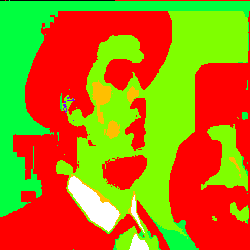

Cleaned up temporary audio file: /content/temp_audio_idontlikeyourtone.mp3


ValueError: Not a valid MMGIF file.

In [32]:
import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output # Import clear_output
import shutil # For removing directories
from datetime import datetime # Import datetime for date metadata
import gc # Import gc for garbage collection

# Include log function definition for self-contained execution
DEBUG = True
def log(*args):
    if DEBUG:
        print(*args)

# --- User-configurable Parameters (now sourced from global config) --- #
try:
    # Using GLOBAL variables defined in Cell 0
    input_video_path = INPUT_VIDEO_PATH
    configurable_bit_depth = GLOBAL_BIT_DEPTH
    configurable_fps = GLOBAL_FPS
    configurable_color_gain = GLOBAL_COLOR_GAIN
except NameError as e:
    raise NameError(f"Configuration variable not found: {e}. Please ensure Cell 0 (Global Configuration) is executed first.") from e

log(f"Using input video file: {input_video_path}")

# --- Universalization and Optimization --- #
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]
output_filename = f"{base_name}_mmgif_{configurable_bit_depth}bit_fps{configurable_fps}_gain{configurable_color_gain}.gif"
output_animated_mmgif_path = f'/content/{output_filename}'

# 2. Temporary audio path
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}. Ensure upload or Drive mount.")

# --- Define extract_frames function locally for self-containment --- #
def extract_frames(video_path, fps=10):
    clip = VideoFileClip(video_path)
    duration = clip.duration
    log(f"Video duration: {duration:.2f} seconds")

    frames = [
        PImage.fromarray(frame)
        for frame in clip.iter_frames(fps=fps, dtype="uint8")
    ]
    clip.close()
    log(f"Extracted {len(frames)} frames from {video_path} at {fps} fps.")
    return frames

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing --- #
    log(f"Extracting audio from {input_video_path}...")
    video_clip_audio = VideoFileClip(input_video_path)
    video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3')
    video_clip_audio.close()
    log("Audio extraction complete.")

    # Load the extracted audio file
    audio = AudioSegment.from_file(audio_temp_path)

    # Convert to mono and get raw samples
    audio = audio.set_channels(1)
    samples = np.array(audio.get_array_of_samples())

    # --- Normalize samples to target bit depth (new symmetric scaling) --- #
    max_target_val = (2**configurable_bit_depth) - 1

    samples = samples.astype(np.float32)
    # Normalize to -1..1
    samples /= np.max(np.abs(samples)) if np.max(np.abs(samples)) > 0 else 1.0
    # Scale to 0-max_target_val
    audio_processed_data = np.clip(((samples + 1) / 2) * max_target_val, 0, max_target_val).astype(np.uint8)

    log(f"Original audio samples length: {len(samples)}")
    log(f"{configurable_bit_depth}-bit audio data length: {len(audio_processed_data)}")
    log(f"Min value in {configurable_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}")

    # --- Frame Extraction (using the global optimized function!) --- #
    log(f"Extracted frames from {input_video_path}...")
    video_frames = extract_frames(input_video_path, fps=configurable_fps) # Use configurable_fps
    log(f"Number of extracted frames: {len(video_frames)}")

    # --- Prepare Custom Metadata --- #
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"MMGIF created by Talos on {current_date}"

    # --- Runtime isolation: Force garbage collection --- #
    gc.collect()
    log("Garbage collection performed for runtime isolation.")

    # --- Encode MMGIF with Animated Background Frames --- #
    log(f"Encoding animated MMGIF to {output_animated_mmgif_path} with {configurable_bit_depth}-bit audio...")
    encode_mmgif(audio_processed_data, output_animated_mmgif_path,
                    background_frames=video_frames, width=250, height=250,
                    bit_depth=configurable_bit_depth, custom_metadata_string=custom_metadata,
                    gif_fps=configurable_fps, color_gain=configurable_color_gain) # Pass new parameters

    log(f"Animated MMGIF saved to: {output_animated_mmgif_path}")

    # Provide a downloadable link
    files.download(output_animated_mmgif_path)

    # --- Display the generated GIF and clear previous output --- #
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_mmgif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_mmgif(output_animated_mmgif_path)
    log(f"Decoded Metadata: {decoded_info['metadata']}")

finally:
    # --- Cleanup --- #
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        log(f"Cleaned up temporary audio file: {audio_temp_path}")

In [ ]:
# Cell 13 - Redundant display cell
# This cell is now redundant as the display is included in the previous cell.

In [31]:
# Cell 14 - Core MMGIF Encoding/Decoding Functions (Updated)

import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
import colorsys
from scipy.spatial import cKDTree # NEW: Import cKDTree
from PIL import ImageEnhance # NEW: Import ImageEnhance for color gain
import json # NEW: For serializing/deserializing metadata

MAGIC = [77, 77, 71, 73, 70]  # "MMGIF"

def encode_mmgif(audio_data, output_path, width=250, height=250, background_frames=None, bit_depth=4, custom_metadata_string="", gif_fps=10, color_gain=0.0):
    audio_data = np.asarray(audio_data, dtype=np.uint8)

    # Validate bit_depth and audio data range
    if not (2 <= bit_depth <= 6):
        raise ValueError("bit_depth must be between 2 and 6.")
    max_audio_val = (2**bit_depth) - 1
    if audio_data.min() < 0 or audio_data.max() > max_audio_val:
        raise ValueError(f"Audio must be {bit_depth}-bit (0–{max_audio_val}).")

    if height < 11:
        raise ValueError("Height must be at least 11 (1 header row + 10 audio rows).")

    audio_rows = 10
    capacity = width * audio_rows

    # pad / truncate
    audio = np.zeros(capacity, dtype=np.uint8)
    audio[:min(len(audio_data), capacity)] = audio_data[:capacity]

    # reshape into image block
    audio_block = audio.reshape(audio_rows, width)

    # --- Generate the MMGIF palette (RGB tuples and flat list for PIL) ---
    mmgif_palette_rgb = []
    for i in range(2**bit_depth):
        # Generate distinct colors for each audio value using HSV
        hue = i / (2**bit_depth) # Normalize hue to 0-1 range
        rgb_float = colorsys.hsv_to_rgb(hue, 1.0, 1.0) # Full saturation, full value
        mmgif_palette_rgb.append(tuple(int(x * 255) for x in rgb_float))

    mmgif_palette_rgb.append((255, 255, 255)) # Index (2**bit_depth) is white (general background color)

    pil_palette = []
    for r, g, b in mmgif_palette_rgb:
        pil_palette.extend([r, g, b])
    # Pad to 256 for PIL
    pil_palette += [0, 0, 0] * (256 - len(pil_palette) // 3)

    # NEW: Prepare KD-tree for nearest color search
    palette_np = np.array(mmgif_palette_rgb, dtype=np.uint8)
    color_tree = cKDTree(palette_np)

    # Prepare metadata for header
    # Combine user custom metadata with encoding info
    full_metadata = {
        "user_meta": custom_metadata_string,
        "bit_depth": bit_depth,
        "gif_fps": gif_fps,
        "color_gain": color_gain
    }
    encoded_metadata = json.dumps(full_metadata).encode('ascii', errors='replace')
    metadata_length = min(len(encoded_metadata), width - 11) # Max 239 chars for default width (250-11)

    # Function to create header row data
    def create_header(current_width, current_len, current_bit_depth, current_metadata_length, current_encoded_metadata):
        header_data = np.zeros(width, dtype=np.uint8)
        header_data[0:5] = MAGIC
        header_data[5] = (current_width // 256) & 255
        header_data[6] = current_width & 255
        header_data[7] = (current_len // 256) & 255
        header_data[8] = current_len & 255
        header_data[9] = current_bit_depth # Store bit depth in header (legacy, now also in JSON metadata)
        header_data[10] = current_metadata_length # Store metadata string length
        if current_metadata_length > 0:
            header_data[11 : 11 + metadata_length] = list(current_encoded_metadata[:current_metadata_length])
        return header_data

    if background_frames:
        output_images = []
        for frame_img in background_frames:
            # Resize the frame to the desired GIF dimensions
            frame_img = frame_img.resize((width, height)).convert('RGB') # Ensure RGB for color matching

            # Apply color gain if not 0
            if color_gain != 0:
                enhancer = ImageEnhance.Brightness(frame_img)
                if color_gain <= 0: # -1 to 0 (darken to original)
                    enhancement_factor = color_gain + 1 # Maps -1 to 0, 0 to 1
                else: # 0 to 1 (original to overexposed)
                    # Maps 0 to 1, 1 to 3 (e.g., 3x brightness for max overexposure)
                    enhancement_factor = 1 + color_gain * 2
                frame_img = enhancer.enhance(enhancement_factor)

            # NEW: Use KD-tree for palette matching
            pixels_rgb = np.array(frame_img).reshape(-1, 3)
            _, closest_palette_indices = color_tree.query(pixels_rgb)
            img_data = closest_palette_indices.reshape(height, width).astype(np.uint8)

            # overlay audio block
            img_data[1:11, :] = audio_block  # rows 1–10 reserved for audio

            # header row (simple metadata)
            img_data[0, :] = create_header(width, len(audio_data), bit_depth, metadata_length, encoded_metadata)

            img = PImage.fromarray(img_data.astype(np.uint8), mode="P")
            img.putpalette(pil_palette)
            output_images.append(img)

        # Save all frames as an animated GIF
        if output_images:
            # Use gif_fps for duration
            output_images[0].save(output_path, save_all=True, append_images=output_images[1:],
                                  duration=int(1000/gif_fps), loop=0, optimize=True)
    else:
        raise ValueError("For MMGIFs, background_frames must be provided.")

def decode_mmgif(path):
    img = PImage.open(path).convert("P") # ADDED .convert("P") back
    data = np.array(img, dtype=np.uint8)

    # verify header
    if list(data[0, 0:5]) != MAGIC:
        raise ValueError("Not a valid MMGIF file.")

    width = int(data[0, 5] << 8 | data[0, 6])
    original_len = int(data[0, 7] << 8 | data[0, 8])
    bit_depth = data[0, 9] # Read bit depth from header (legacy)
    metadata_length = data[0, 10] # Read metadata string length

    custom_metadata_string = ""
    user_metadata = ""
    decoded_bit_depth = bit_depth # Default to legacy header value
    decoded_gif_fps = 10
    decoded_color_gain = 0.0

    if metadata_length > 0:
        try:
            # Attempt to decode as JSON
            metadata_bytes = bytes(data[0, 11 : 11 + metadata_length])
            full_metadata = json.loads(metadata_bytes.decode('ascii', errors='replace'))
            user_metadata = full_metadata.get("user_meta", "")
            decoded_bit_depth = full_metadata.get("bit_depth", bit_depth)
            decoded_gif_fps = full_metadata.get("gif_fps", 10)
            decoded_color_gain = full_metadata.get("color_gain", 0.0)
            custom_metadata_string = user_metadata # Assign user_metadata to custom_metadata_string
        except json.JSONDecodeError:
            # Fallback for old format or non-JSON metadata
            custom_metadata_string = bytes(data[0, 11 : 11 + metadata_length]).decode('ascii', errors='replace')

    audio_block = data[1:11, :].reshape(-1)

    return {"audio_data": audio_block[:original_len],
            "width": width,
            "original_len": original_len,
            "bit_depth": decoded_bit_depth, # Return parsed bit_depth
            "metadata": custom_metadata_string,
            "gif_fps": decoded_gif_fps,
            "color_gain": decoded_color_gain}

In [ ]:
# Cell 15 - Loads and processes MP3 audio to 4-bit data

from pydub import AudioSegment
import numpy as np

# Load the audio file
audio_path = '/content/hoi4-telegram-101soundboards.mp3'
audio = AudioSegment.from_mp3(audio_path)

# Convert to mono and get raw samples
audio = audio.set_channels(1)
samples = np.array(audio.get_array_of_samples())

# Normalize samples to 0-15 range (4-bit)
# Assuming signed 16-bit audio, range is -32768 to 32767
max_val = np.iinfo(samples.dtype).max
min_val = np.iinfo(samples.dtype).min

normalized_samples = (samples - min_val) / (max_val - min_val) # Scale to 0-1
audio_4bit_data = np.clip(normalized_samples * 15, 0, 15).astype(np.uint8) # Clip to ensure 0-15 range

print(f"Original audio samples length: {len(samples)}")
print(f"4-bit audio data length: {len(audio_4bit_data)}")
print(f"Min value in 4-bit data: {audio_4bit_data.min()}, Max value: {audio_4bit_data.max()}")

In [ ]:
# Cell 16 - (Previously encoded static Audiogif - now obsolete)

# Cell 17 - (Previously markdown explanation for static Audiogif - now obsolete)

In [ ]:
# Cell 18 - (Previously displayed static Audiogif - now obsolete)

# Cell 19 - (Previously duplicate markdown explanation for static Audiogif - now obsolete)

In [ ]:
# Cell 20 - Placeholder for animated GIF to audio merging

# To combine an animated GIF with your audio, please upload the animated GIF file here.
# from google.colab import files
# uploaded = files.upload()
# animated_gif_path = list(uploaded.keys())[0]

# Placeholder for future code to process the animated GIF and merge with audio.
# We will use ffmpeg to convert the GIF to a video and then merge it with the audio.
# This cell will be updated once you provide an animated GIF.